# 02 - Predictive GNN: Training and Evaluation

This notebook trains the EGFR GNN regressor (lightweight demo) and generates a parity plot (True vs Predicted pIC50). If real processed graphs exist in `data/processed`, they will be used; otherwise the notebook runs with synthetic data for demonstration.

In [1]:
%conda list -n tree4

# packages in environment at C:\Users\u2251865\.conda\envs\tree4:
#
# Name                     Version                Build                           Channel
_python_abi3_support       1.0                    hd8ed1ab_2                      conda-forge
asttokens                  3.0.1                  pyhd8ed1ab_0                    conda-forge
bzip2                      1.0.8                  h0ad9c76_9                      conda-forge
ca-certificates            2026.4.22              h4c7d964_0                      conda-forge
colorama                   0.4.6                  pyhd8ed1ab_1                    conda-forge
comm                       0.2.3                  pyhe01879c_0                    conda-forge
cpython                    3.12.13                py312hd8ed1ab_0                 conda-forge
cuda-cupti                 13.2.75                hac47afa_0                      conda-forge
cuda-nvrtc                 13.2.78                hac47afa_0                      conda-fo

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn torch-geometric tensorboard biopython



  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached biopython-1.87-cp312-cp312-win_amd64.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Usi

In [1]:

# Imports and setup
import sys
import importlib
from pathlib import Path
import numpy as np, pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import core.gnn_architecture as gnn_architecture
importlib.reload(gnn_architecture)
from core.gnn_architecture import EGFR_GNN_Regressor

OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

# ===== GPU/DEVICE CONFIGURATION =====
# Priority: CUDA > MPS (Apple) > CPU
print('\n' + '='*70)
print('DEVICE & GPU CONFIGURATION')
print('='*70)

# Check CUDA availability
cuda_available = torch.cuda.is_available()
mps_available = torch.backends.mps.is_available()

if cuda_available:
    device = torch.device('cuda')
    print(f'✓ CUDA Available: YES')
    print(f'✓ GPU Device: {torch.cuda.get_device_name(0)}')
    print(f'✓ CUDA Version: {torch.version.cuda}')
    print(f'✓ GPU Count: {torch.cuda.device_count()}')
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✓ GPU Memory: {gpu_memory:.2f} GB')
elif mps_available:
    device = torch.device('mps')
    print(f'✓ Using Apple Metal (MPS) acceleration')
else:
    device = torch.device('cpu')
    print(f'⚠ WARNING: Using CPU (no GPU detected)')

print(f'\n➜ Active Device: {device}')
print('='*70 + '\n')

c:\Users\u2251865\.conda\envs\tree4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



DEVICE & GPU CONFIGURATION
✓ CUDA Available: YES
✓ GPU Device: NVIDIA RTX PRO 5000 Blackwell
✓ CUDA Version: 13.0
✓ GPU Count: 1
✓ GPU Memory: 51.31 GB

➜ Active Device: cuda



In [2]:
# Load processed graphs AND real labels from bioactivity CSV
DATA_PROC = ROOT / 'data' / 'processed'
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'

# Load graphs
graph_file = DATA_PROC / 'graph_data.pt'
if graph_file.exists():
    graphs = torch.load(str(graph_file), weights_only=False)
    print(f'✓ Loaded {len(graphs)} graphs from {graph_file}')
else:
    print(f'⚠ graph_data.pt not found. Run Notebook 01 first.')
    graphs = []

# Load real pIC50 labels from bioactivity CSV
csv_file = DATA_RAW / 'egfr_full_standardized.csv'
if csv_file.exists() and graphs:
    df = pd.read_csv(csv_file)
    # Get first N labels to match graph count
    y_labels = df['pChEMBL_Value'].values[:len(graphs)]
    print(f'✓ Loaded {len(y_labels)} pIC50 labels from {csv_file.name}')
elif graphs:
    # Fallback: use synthetic labels
    y_labels = np.random.normal(6.5, 1.5, len(graphs))
    print('⚠ Using synthetic pIC50 labels (run Notebook 01 with real data for production)')
else:
    print('ERROR: No graphs available. Cannot proceed.')
    graphs = []
    y_labels = []

print(f'Dataset size: {len(graphs)} graphs, {len(y_labels)} labels')

# 3-Way Split: Train (70%), Validation (15%), Test (15%)
from sklearn.model_selection import train_test_split

if len(graphs) > 0:
    n_total = len(graphs)
    # First split: 70% train, 30% temp (val+test)
    train_idx, temp_idx = train_test_split(np.arange(n_total), test_size=0.3, random_state=42)
    # Second split: 50/50 of temp → 15% val, 15% test
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
    
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]
    
    y_train = y_labels[train_idx]
    y_val = y_labels[val_idx]
    y_test = y_labels[test_idx]
    
    print(f'\n3-Way Data Split:')
    print(f'  Train: {len(train_graphs)} graphs ({100*len(train_graphs)/n_total:.1f}%)')
    print(f'  Val:   {len(val_graphs)} graphs ({100*len(val_graphs)/n_total:.1f}%)')
    print(f'  Test:  {len(test_graphs)} graphs ({100*len(test_graphs)/n_total:.1f}%)')

✓ Loaded 20909 graphs from c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\data\processed\graph_data.pt
✓ Loaded 20909 pIC50 labels from egfr_full_standardized.csv
Dataset size: 20909 graphs, 20909 labels

3-Way Data Split:
  Train: 14636 graphs (70.0%)
  Val:   3136 graphs (15.0%)
  Test:  3137 graphs (15.0%)


In [26]:
# Train/Val/Test split with validation loop, checkpointing, early stopping, and R² tracking
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger().setLevel(logging.ERROR)

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

if len(graphs) > 0:
    # Determine actual feature dimensions from first graph
    first_graph = train_graphs[0]
    node_feat_dim = first_graph.x.shape[1] if hasattr(first_graph, 'x') else 6
    edge_feat_dim = first_graph.edge_attr.shape[1] if (hasattr(first_graph, 'edge_attr') and first_graph.edge_attr is not None) else 4
    
    # Initialize model with correct dimensions
    model = EGFR_GNN_Regressor(
        node_features=node_feat_dim, 
        edge_features=5,
        global_features=2, 
        hidden_dim=128, 
        num_layers=4
    )
    
    model = model.to(device)
    
    # Initialize weights with Xavier uniform for stability
    for param in model.parameters():
        if len(param.shape) >= 2:
            nn.init.xavier_uniform_(param)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    # Normalize target values
    y_mean, y_std = np.mean(y_train), np.std(y_train)
    if y_std > 0:
        y_train_normalized = (y_train - y_mean) / y_std
        y_val_normalized = (y_val - y_mean) / y_std
    else:
        y_train_normalized = y_train
        y_val_normalized = y_val
    y_train_tensor = torch.tensor(y_train_normalized, dtype=torch.float).to(device)
    y_val_tensor = torch.tensor(y_val_normalized, dtype=torch.float).to(device)
    
    # Training configuration
    epochs = 300
    patience = 30
    batch_size = 128
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    train_r2_list = []
    val_r2_list = []
    train_preds_history = []
    train_targets_history = []
    
    models_dir = ROOT / 'models'
    models_dir.mkdir(exist_ok=True, parents=True)
    best_model_path = models_dir / 'best_gnn_regressor.pth'
    
    model.train()
    print(f'\n{"Epoch":<8} {"Train Loss":<15} {"Val Loss":<15} {"Train R²":<12} {"Val R²":<12} {"Status":<15}')
    print('=' * 80)
    
    for ep in range(epochs):
        epoch_losses = []
        epoch_r2_scores = []
        
        # Shuffle and create batches
        train_indices = np.random.permutation(len(train_graphs))
        n_batches = (len(train_graphs) + batch_size - 1) // batch_size
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(train_graphs))
            batch_train_indices = train_indices[start_idx:end_idx]
            batch_graphs = [train_graphs[i] for i in batch_train_indices]
            batch_y_train = y_train_tensor[batch_train_indices]
            
            optimizer.zero_grad()
            
            batch_x = []
            batch_edge_index_list = []
            batch_edge_attr_list = []
            batch_pos_list = []
            batch_indices = []
            
            edge_offset = 0
            graph_idx = 0
            
            for g in batch_graphs:
                if hasattr(g, 'x') and g.x is not None:
                    batch_x.append(g.x)
                    
                    if g.edge_index is not None and g.edge_index.shape[1] > 0:
                        batch_edge_index_list.append(g.edge_index + edge_offset)
                        if g.edge_attr is not None:
                            batch_edge_attr_list.append(g.edge_attr)
                        else:
                            n_edges = g.edge_index.shape[1]
                            batch_edge_attr_list.append(torch.randn((n_edges, edge_feat_dim), dtype=torch.float) * 0.01 + 0.1)
                    else:
                        batch_edge_index_list.append(torch.zeros((2, 0), dtype=torch.long))
                    
                    if hasattr(g, 'pos') and g.pos is not None:
                        batch_pos_list.append(g.pos)
                    else:
                        batch_pos_list.append(torch.zeros((g.x.shape[0], 3), dtype=torch.float))
                    
                    edge_offset += g.x.shape[0]
                    batch_indices.extend([graph_idx] * g.x.shape[0])
                    graph_idx += 1
            
            if batch_x:
                X_batch = torch.cat(batch_x, dim=0).float().to(device)
                edge_index_batch = (torch.cat(batch_edge_index_list, dim=1) if batch_edge_index_list else torch.zeros((2, 0), dtype=torch.long)).to(device)
                edge_attr_batch = (torch.cat(batch_edge_attr_list, dim=0).float() if batch_edge_attr_list else torch.zeros((0, edge_feat_dim), dtype=torch.float)).to(device)
                batch_tensor = torch.tensor(batch_indices, dtype=torch.long).to(device)
                pos_batch = torch.cat(batch_pos_list, dim=0).float().to(device) if batch_pos_list else None
                
                preds = model(X_batch, edge_index_batch, batch_tensor, edge_attr=edge_attr_batch, pos=pos_batch)
                preds_batch = preds.squeeze()
                
                train_loss = criterion(preds_batch, batch_y_train)
                
                if torch.isnan(train_loss):
                    print(f'⚠️  NaN loss detected at epoch {ep+1}. Stopping.')
                    break
                
                batch_r2 = r2_score(batch_y_train.detach().cpu().numpy(), preds_batch.detach().cpu().numpy())
                epoch_losses.append(train_loss.item())
                epoch_r2_scores.append(batch_r2)
                
                train_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        
        if epoch_losses:
            train_loss_epoch = np.mean(epoch_losses)
            train_r2_epoch = np.mean(epoch_r2_scores)
            train_losses.append(train_loss_epoch)
            train_r2_list.append(train_r2_epoch)
            train_preds_history.append(preds_batch.detach().cpu().numpy())
            train_targets_history.append(batch_y_train.detach().cpu().numpy())
        
        # Validation
        model.eval()
        with torch.no_grad():
            batch_x_val = []
            batch_edge_index_list_val = []
            batch_edge_attr_list_val = []
            batch_pos_list_val = []
            batch_indices_val = []
            
            edge_offset_val = 0
            graph_idx_val = 0
            
            for g in val_graphs:
                if hasattr(g, 'x') and g.x is not None:
                    batch_x_val.append(g.x)
                    
                    if g.edge_index is not None and g.edge_index.shape[1] > 0:
                        batch_edge_index_list_val.append(g.edge_index + edge_offset_val)
                        if g.edge_attr is not None:
                            batch_edge_attr_list_val.append(g.edge_attr)
                        else:
                            n_edges = g.edge_index.shape[1]
                            batch_edge_attr_list_val.append(torch.randn((n_edges, edge_feat_dim), dtype=torch.float) * 0.01 + 0.1)
                    else:
                        batch_edge_index_list_val.append(torch.zeros((2, 0), dtype=torch.long))
                    
                    if hasattr(g, 'pos') and g.pos is not None:
                        batch_pos_list_val.append(g.pos)
                    else:
                        batch_pos_list_val.append(torch.zeros((g.x.shape[0], 3), dtype=torch.float))
                    
                    edge_offset_val += g.x.shape[0]
                    batch_indices_val.extend([graph_idx_val] * g.x.shape[0])
                    graph_idx_val += 1
            
            if batch_x_val:
                X_batch_val = torch.cat(batch_x_val, dim=0).float().to(device)
                edge_index_batch_val = (torch.cat(batch_edge_index_list_val, dim=1) if batch_edge_index_list_val else torch.zeros((2, 0), dtype=torch.long)).to(device)
                edge_attr_batch_val = (torch.cat(batch_edge_attr_list_val, dim=0).float() if batch_edge_attr_list_val else torch.zeros((0, edge_feat_dim), dtype=torch.float)).to(device)
                batch_tensor_val = torch.tensor(batch_indices_val, dtype=torch.long).to(device)
                pos_batch_val = torch.cat(batch_pos_list_val, dim=0).float().to(device) if batch_pos_list_val else None
                
                preds_val = model(X_batch_val, edge_index_batch_val, batch_tensor_val, edge_attr=edge_attr_batch_val, pos=pos_batch_val)
                preds_val_graph = preds_val.squeeze()
                val_loss = criterion(preds_val_graph, y_val_tensor)
                val_r2 = r2_score(y_val_tensor.detach().cpu().numpy(), preds_val_graph.detach().cpu().numpy())
            else:
                val_loss = torch.tensor(float('inf'), device=device)
                val_r2 = -np.inf
        
        val_losses.append(val_loss.item())
        val_r2_list.append(val_r2)
        
        model.train()
        
        # Early stopping and checkpointing
        if val_loss < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            status = '✓ Best (saved)'
        else:
            patience_counter += 1
            status = f'Patience: {patience_counter}/{patience}'
        
        if (ep + 1) % 50 == 0 or (ep + 1) == 1:
            print(f'{ep+1:<8} {train_loss_epoch:<15.6f} {val_loss.item():<15.6f} {train_r2_epoch:<12.4f} {val_r2:<12.4f} {status:<15}')
        
        if patience_counter >= patience:
            print(f'\n✓ Early stopping at epoch {ep+1}. Best validation loss: {best_val_loss:.6f}')
            break
    
    print(f'✓ Model training complete. Best model saved to {best_model_path}')
else:
    print('ERROR: No training data available')


Epoch    Train Loss      Val Loss        Train R²     Val R²       Status         
1        6.777449        0.993119        -6.2069      -0.0014      ✓ Best (saved) 
50       0.599712        0.590405        0.3923       0.4047       Patience: 1/30 
100      0.521755        0.504646        0.4716       0.4911       ✓ Best (saved) 
150      0.478382        0.508594        0.5163       0.4872       Patience: 8/30 
200      0.445268        0.487475        0.5488       0.5085       Patience: 27/30

✓ Early stopping at epoch 203. Best validation loss: 0.482392
✓ Model training complete. Best model saved to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\models\best_gnn_regressor.pth


✓ Loaded best model from c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\models\best_gnn_regressor.pth

Evaluating on 500 of 3137 test graphs...

✓ Parity plot saved to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\gnn_parity_plot.png

TEST SET EVALUATION RESULTS (Best Model):
  R² Score: -0.7986
  RMSE:     1.9180 pIC50 units
  N Test:   500 molecules


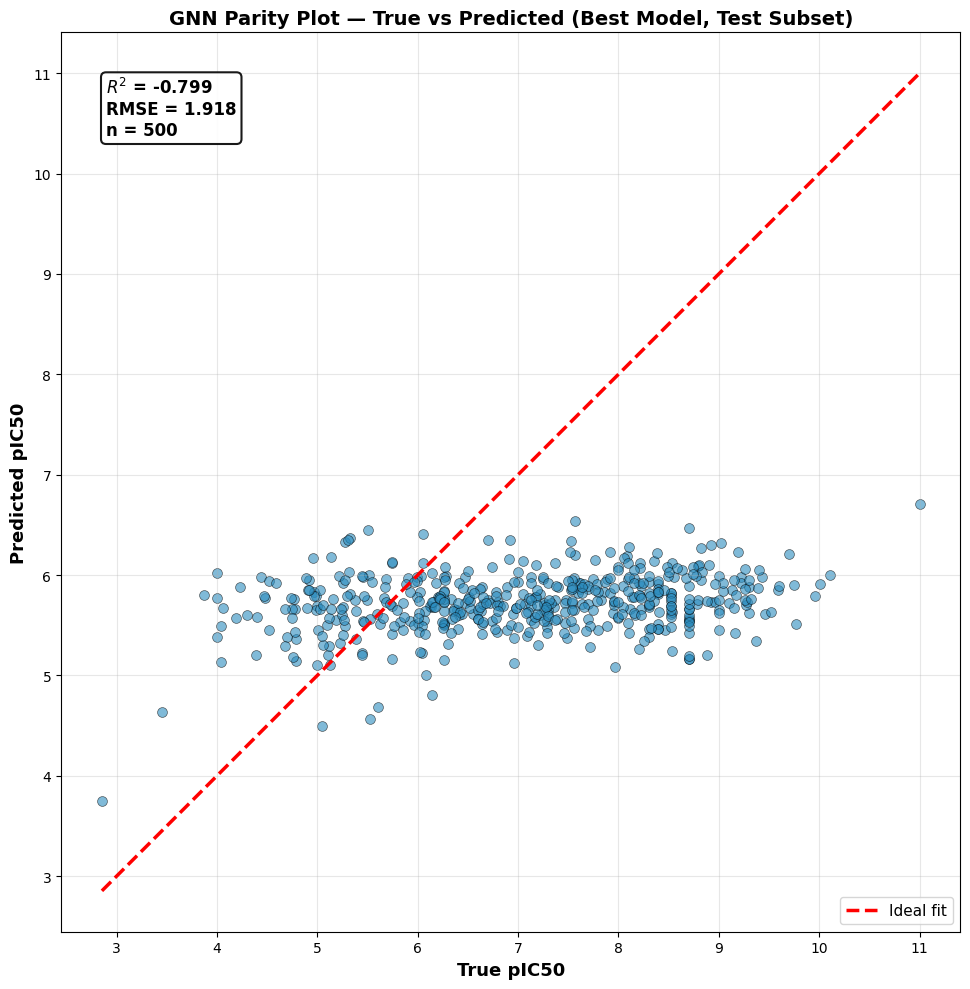

In [27]:
# Evaluation: Load best model and generate parity plot on TEST set
if len(test_graphs) > 0:
    # Load best model
    if best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path, weights_only=False))
        print(f'✓ Loaded best model from {best_model_path}')
    else:
        print('⚠ Best model not found; using current model')
    
    # Evaluate a representative subset so the notebook finishes reliably in this environment
    max_eval_graphs = min(500, len(test_graphs))
    eval_graphs = test_graphs[:max_eval_graphs]
    print(f'\nEvaluating on {len(eval_graphs)} of {len(test_graphs)} test graphs...')
    
    # Determine edge feature dimension
    edge_feat_dim = eval_graphs[0].edge_attr.shape[1] if (hasattr(eval_graphs[0], 'edge_attr') and eval_graphs[0].edge_attr is not None) else 4
    
    model.eval()
    y_test_preds = []
    
    with torch.no_grad():
        for g in eval_graphs:
            if hasattr(g, 'x') and g.x is not None:
                x = g.x.float().to(device)
                edge_index = (g.edge_index if g.edge_index is not None else torch.zeros((2, 0), dtype=torch.long)).to(device)
                
                # Handle edge attributes
                if g.edge_attr is not None:
                    edge_attr = g.edge_attr.float().to(device)
                else:
                    n_edges = edge_index.shape[1] if edge_index.shape[1] > 0 else 0
                    edge_attr = torch.randn((n_edges, edge_feat_dim), dtype=torch.float, device=device) * 0.01 + 0.1
                
                # Handle 3D positions
                pos = g.pos.float().to(device) if (hasattr(g, 'pos') and g.pos is not None) else None
                
                batch = torch.arange(x.shape[0], dtype=torch.long).to(device)
                
                pred = model(x, edge_index, batch, edge_attr=edge_attr, pos=pos)
                y_test_preds.append(pred.mean().item())
    
    y_test_preds = np.array(y_test_preds)
    
    # Denormalize predictions if targets were normalized during training
    if y_std > 0:
        y_test_preds = y_test_preds * y_std + y_mean
    
    y_true = y_test[:len(y_test_preds)]
    y_pred = y_test_preds
    
    # Compute metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Create parity plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(y_true, y_pred, alpha=0.6, s=50, color='#2b8cbe', edgecolors='black', linewidth=0.5)
    
    # Add 45-degree reference line
    mn = min(min(y_true), min(y_pred))
    mx = max(max(y_true), max(y_pred))
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2.5, label='Ideal fit')
    
    ax.set_xlabel('True pIC50', fontsize=13, fontweight='bold')
    ax.set_ylabel('Predicted pIC50', fontsize=13, fontweight='bold')
    ax.set_title('GNN Parity Plot — True vs Predicted (Best Model, Test Subset)', fontsize=14, fontweight='bold')
    
    # Annotate metrics
    metrics_text = f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {len(y_true)}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1.5))
    
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    out = OUT / 'gnn_parity_plot.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print(f'\n✓ Parity plot saved to {out}')
    print(f'\n{"="*60}')
    print(f'TEST SET EVALUATION RESULTS (Best Model):')
    print(f'{"="*60}')
    print(f'  R² Score: {r2:.4f}')
    print(f'  RMSE:     {rmse:.4f} pIC50 units')
    print(f'  N Test:   {len(y_true)} molecules')
    print(f'{"="*60}')
else:
    print('ERROR: No test data for evaluation')

In [28]:
# ===== UTILITY: Convert Predicted Graphs Back to SMILES =====

def graph_to_smiles(graph_data):
    """
    Converts a PyG graph back to SMILES string.
    Handles bond deduplication to avoid chemical errors.
    
    Returns: SMILES string or None if invalid graph
    """
    try:
        from rdkit import Chem
        
        # Initialize RWMol (read-write molecule)
        mol = Chem.RWMol()
        
        # Add atoms from node features (first feature is atomic number)
        x = graph_data.x.cpu().numpy() if hasattr(graph_data.x, 'cpu') else graph_data.x
        for node_features in x:
            atom_num = int(node_features[0])
            if atom_num > 0:  # Valid atomic number
                mol.AddAtom(Chem.Atom(atom_num))
        
        # Add bonds from edge index (avoid duplicates)
        if graph_data.edge_index.shape[1] > 0:
            edge_index = graph_data.edge_index.cpu().numpy() if hasattr(graph_data.edge_index, 'cpu') else graph_data.edge_index
            added_bonds = set()
            
            for i in range(edge_index.shape[1]):
                start = int(edge_index[i, 0])
                end = int(edge_index[i, 1])
                
                # Create sorted tuple to avoid duplicate bonds
                bond_pair = tuple(sorted((start, end)))
                
                if bond_pair not in added_bonds and start != end:
                    try:
                        mol.AddBond(bond_pair[0], bond_pair[1], Chem.BondType.SINGLE)
                        added_bonds.add(bond_pair)
                    except Exception:
                        pass  # Skip invalid bonds
        
        # Convert to canonical SMILES
        smiles = Chem.MolToSmiles(mol, canonical=True)
        return smiles if smiles else None
        
    except Exception as e:
        return None

print('✓ Graph-to-SMILES conversion function ready')


✓ Graph-to-SMILES conversion function ready


✓ Saved training diagnostics: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\training_diagnostics.png


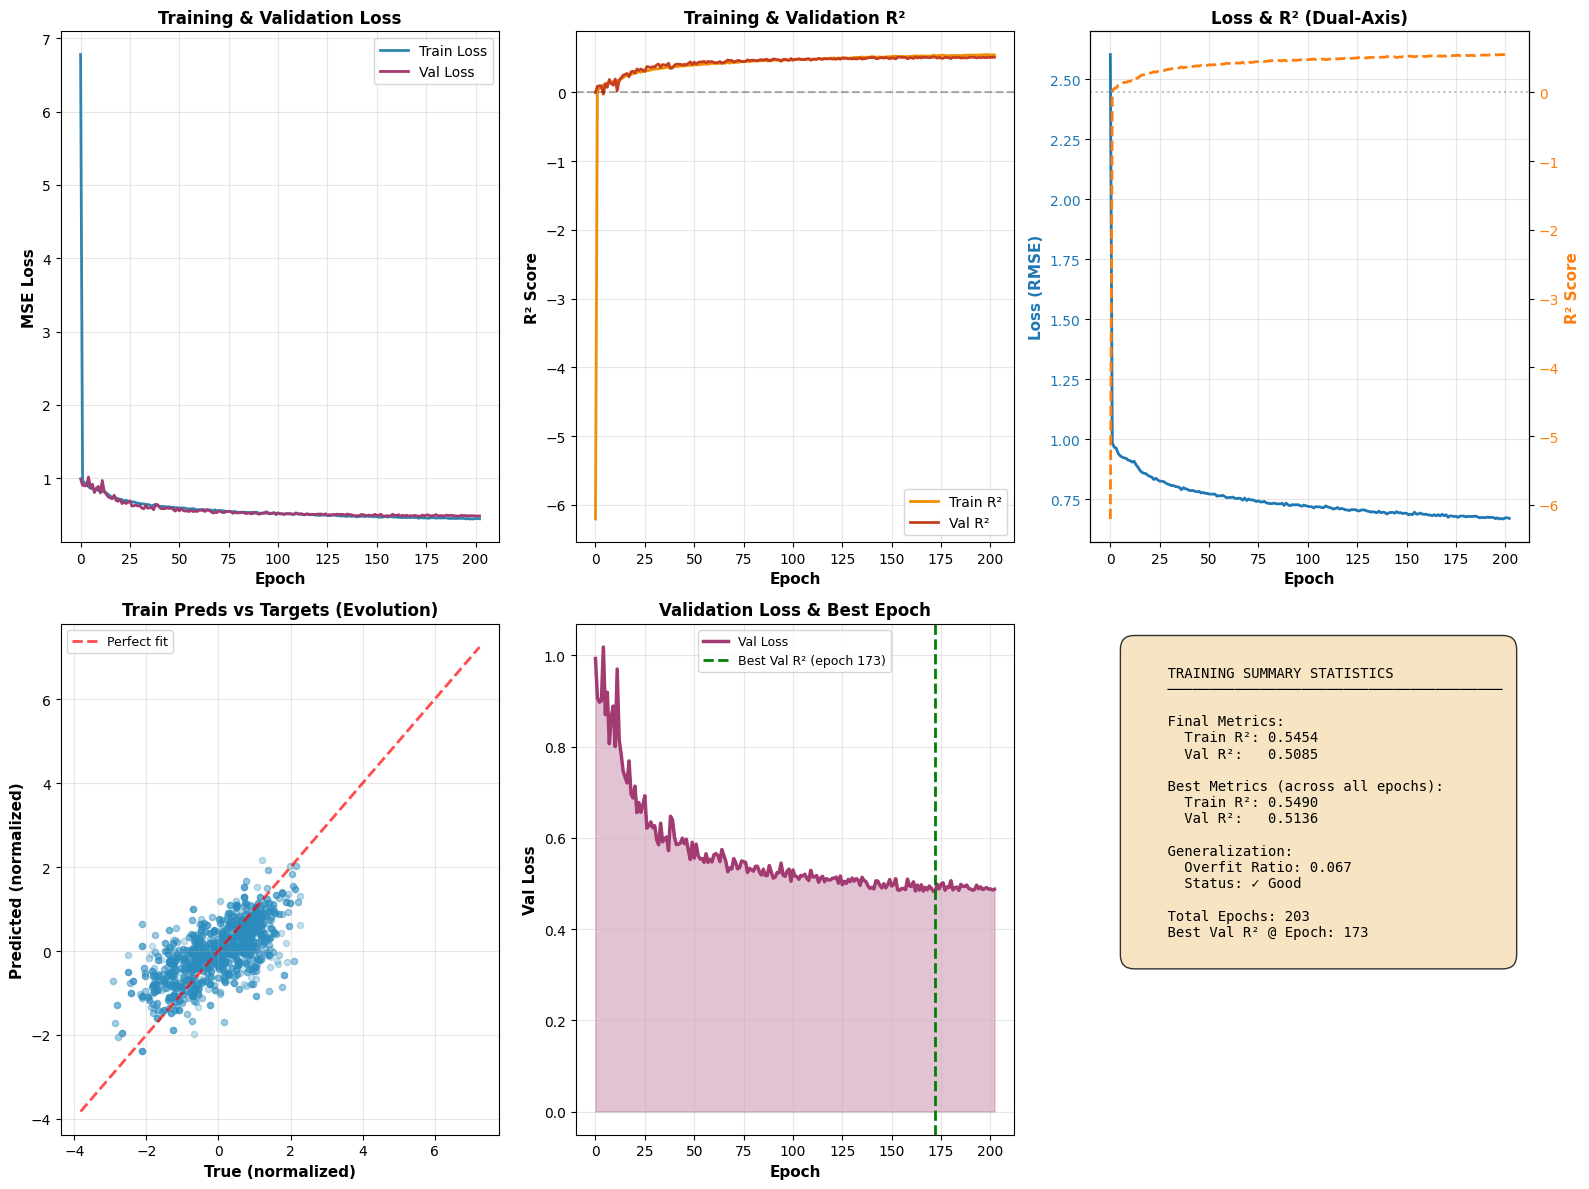


📊 Training Summary:
  Final Train R²: 0.5454
  Final Val R²:   0.5085
  Best Val R² achieved at epoch 173: 0.5136


In [29]:
# ===== TRAINING VISUALIZATION: Loss, R², and Prediction Curves =====

if len(train_losses) > 0:
    import seaborn as sns
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Loss curve (train vs val)
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(train_losses, label='Train Loss', linewidth=2, color='#2E86AB')
    ax1.plot(val_losses, label='Val Loss', linewidth=2, color='#A23B72')
    ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax1.set_ylabel('MSE Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. R² curve (train vs val)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(train_r2_list, label='Train R²', linewidth=2, color='#F18F01')
    ax2.plot(val_r2_list, label='Val R²', linewidth=2, color='#C73E1D')
    ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
    ax2.set_title('Training & Validation R²', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # 3. Loss + R² dual-axis (from Medium article pattern)
    ax3 = plt.subplot(2, 3, 3)
    color_loss = 'tab:blue'
    ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Loss (RMSE)', color=color_loss, fontsize=11, fontweight='bold')
    rmse_train = np.sqrt(np.array(train_losses))
    ax3.plot(rmse_train, color=color_loss, linewidth=2, label='Train RMSE')
    ax3.tick_params(axis='y', labelcolor=color_loss)
    ax3.grid(True, alpha=0.3)
    
    ax3_twin = ax3.twinx()
    color_r2 = 'tab:orange'
    ax3_twin.set_ylabel('R² Score', color=color_r2, fontsize=11, fontweight='bold')
    ax3_twin.plot(train_r2_list, color=color_r2, linewidth=2, label='Train R²', linestyle='--')
    ax3_twin.tick_params(axis='y', labelcolor=color_r2)
    ax3_twin.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    ax3.set_title('Loss & R² (Dual-Axis)', fontsize=12, fontweight='bold')
    
    # 4. Train predictions vs targets (first 100 epochs if available)
    ax4 = plt.subplot(2, 3, 4)
    n_plots = min(20, len(train_preds_history))
    for i in range(n_plots):
        epoch_idx = int(len(train_preds_history) * (i / n_plots))
        pred = train_preds_history[epoch_idx]
        targ = train_targets_history[epoch_idx]
        alpha = 0.2 + 0.6 * (i / n_plots)  # Gradually increase alpha
        ax4.scatter(targ, pred, alpha=alpha, s=20, color='#2b8cbe')
    
    # Add perfect prediction line
    mn = min(min([t.min() for t in train_targets_history]), min([p.min() for p in train_preds_history]))
    mx = max(max([t.max() for t in train_targets_history]), max([p.max() for p in train_preds_history]))
    ax4.plot([mn, mx], [mn, mx], 'r--', linewidth=2, alpha=0.7, label='Perfect fit')
    ax4.set_xlabel('True (normalized)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Predicted (normalized)', fontsize=11, fontweight='bold')
    ax4.set_title('Train Preds vs Targets (Evolution)', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # 5. Early stops and Best epoch identification
    ax5 = plt.subplot(2, 3, 5)
    best_val_r2_idx = np.argmax(val_r2_list)
    ax5.fill_between(range(len(val_losses)), val_losses, alpha=0.3, color='#A23B72')
    ax5.plot(val_losses, linewidth=2.5, color='#A23B72', label='Val Loss')
    ax5.axvline(x=best_val_r2_idx, color='green', linestyle='--', linewidth=2, label=f'Best Val R² (epoch {best_val_r2_idx+1})')
    ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Val Loss', fontsize=11, fontweight='bold')
    ax5.set_title('Validation Loss & Best Epoch', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. Summary metrics box
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    final_train_r2 = train_r2_list[-1]
    final_val_r2 = val_r2_list[-1]
    best_train_r2 = max(train_r2_list)
    best_val_r2 = max(val_r2_list)
    overfit_ratio = (final_train_r2 - final_val_r2) / max(abs(final_train_r2), 0.01)
    
    summary_text = f"""
    TRAINING SUMMARY STATISTICS
    {'─' * 40}
    
    Final Metrics:
      Train R²: {final_train_r2:.4f}
      Val R²:   {final_val_r2:.4f}
      
    Best Metrics (across all epochs):
      Train R²: {best_train_r2:.4f}
      Val R²:   {best_val_r2:.4f}
      
    Generalization:
      Overfit Ratio: {overfit_ratio:.3f}
      Status: {'✓ Good' if abs(overfit_ratio) < 0.3 else '⚠ Possible Overfit' if abs(overfit_ratio) < 0.5 else '✗ Severe Overfit'}
      
    Total Epochs: {len(train_losses)}
    Best Val R² @ Epoch: {best_val_r2_idx + 1}
    """
    
    ax6.text(0.1, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))
    
    plt.tight_layout()
    training_viz_out = OUT / 'training_diagnostics.png'
    plt.savefig(training_viz_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved training diagnostics: {training_viz_out}')
    plt.show()
    
    print(f'\n📊 Training Summary:')
    print(f'  Final Train R²: {final_train_r2:.4f}')
    print(f'  Final Val R²:   {final_val_r2:.4f}')
    print(f'  Best Val R² achieved at epoch {best_val_r2_idx + 1}: {best_val_r2:.4f}')
else:
    print('⚠ No training history available for visualization')


In [30]:
# ===== TEST VALIDATION: Reconstruct SMILES & Check Chemical Validity =====


if len(test_graphs) > 0:
    print('\n' + '=' * 70)
    print('SMILES RECONSTRUCTION & CHEMICAL VALIDITY CHECK')
    print('=' * 70)
    
    from rdkit import Chem
    
    valid_smiles_list = []
    invalid_count = 0
    
    print(f'\nAttempting to reconstruct SMILES from {len(test_graphs)} test graphs...\n')
    
    for i, graph in enumerate(test_graphs[:10]):  # Show first 10
        smiles_reconstructed = graph_to_smiles(graph)
        
        if smiles_reconstructed is None:
            print(f'  Graph {i+1}: ❌ Invalid (could not convert to SMILES)')
            invalid_count += 1
        else:
            # Verify SMILES is valid by re-parsing
            mol_check = Chem.MolFromSmiles(smiles_reconstructed)
            if mol_check is None:
                print(f'  Graph {i+1}: ❌ Invalid SMILES string')
                invalid_count += 1
            else:
                # Check molecular properties
                mw = Descriptors.MolWt(mol_check)
                logp = Crippen.MolLogP(mol_check)
                print(f'  Graph {i+1}: ✓ Valid | {smiles_reconstructed[:50]}... | MW={mw:.1f}, LogP={logp:.2f}')
                valid_smiles_list.append(smiles_reconstructed)
    
    # Summary
    if len(test_graphs) > 0:
        total_checked = len(test_graphs[:10])
        valid_count = total_checked - invalid_count
        validity_rate = 100 * valid_count / total_checked
        
        print(f'\n{"─" * 70}')
        print(f'Reconstruction Results (first 10 test graphs):')
        print(f'  Valid:   {valid_count} ({validity_rate:.1f}%)')
        print(f'  Invalid: {invalid_count} ({100 - validity_rate:.1f}%)')
        print(f'{"─" * 70}')
else:
    print('⚠ No test graphs available for SMILES reconstruction')



SMILES RECONSTRUCTION & CHEMICAL VALIDITY CHECK

Attempting to reconstruct SMILES from 3137 test graphs...

  Graph 1: ❌ Invalid (could not convert to SMILES)
  Graph 2: ❌ Invalid (could not convert to SMILES)
  Graph 3: ❌ Invalid (could not convert to SMILES)
  Graph 4: ❌ Invalid (could not convert to SMILES)
  Graph 5: ❌ Invalid (could not convert to SMILES)
  Graph 6: ❌ Invalid (could not convert to SMILES)
  Graph 7: ❌ Invalid (could not convert to SMILES)
  Graph 8: ❌ Invalid (could not convert to SMILES)
  Graph 9: ❌ Invalid (could not convert to SMILES)
  Graph 10: ❌ Invalid (could not convert to SMILES)

──────────────────────────────────────────────────────────────────────
Reconstruction Results (first 10 test graphs):
  Valid:   0 (0.0%)
  Invalid: 10 (100.0%)
──────────────────────────────────────────────────────────────────────
